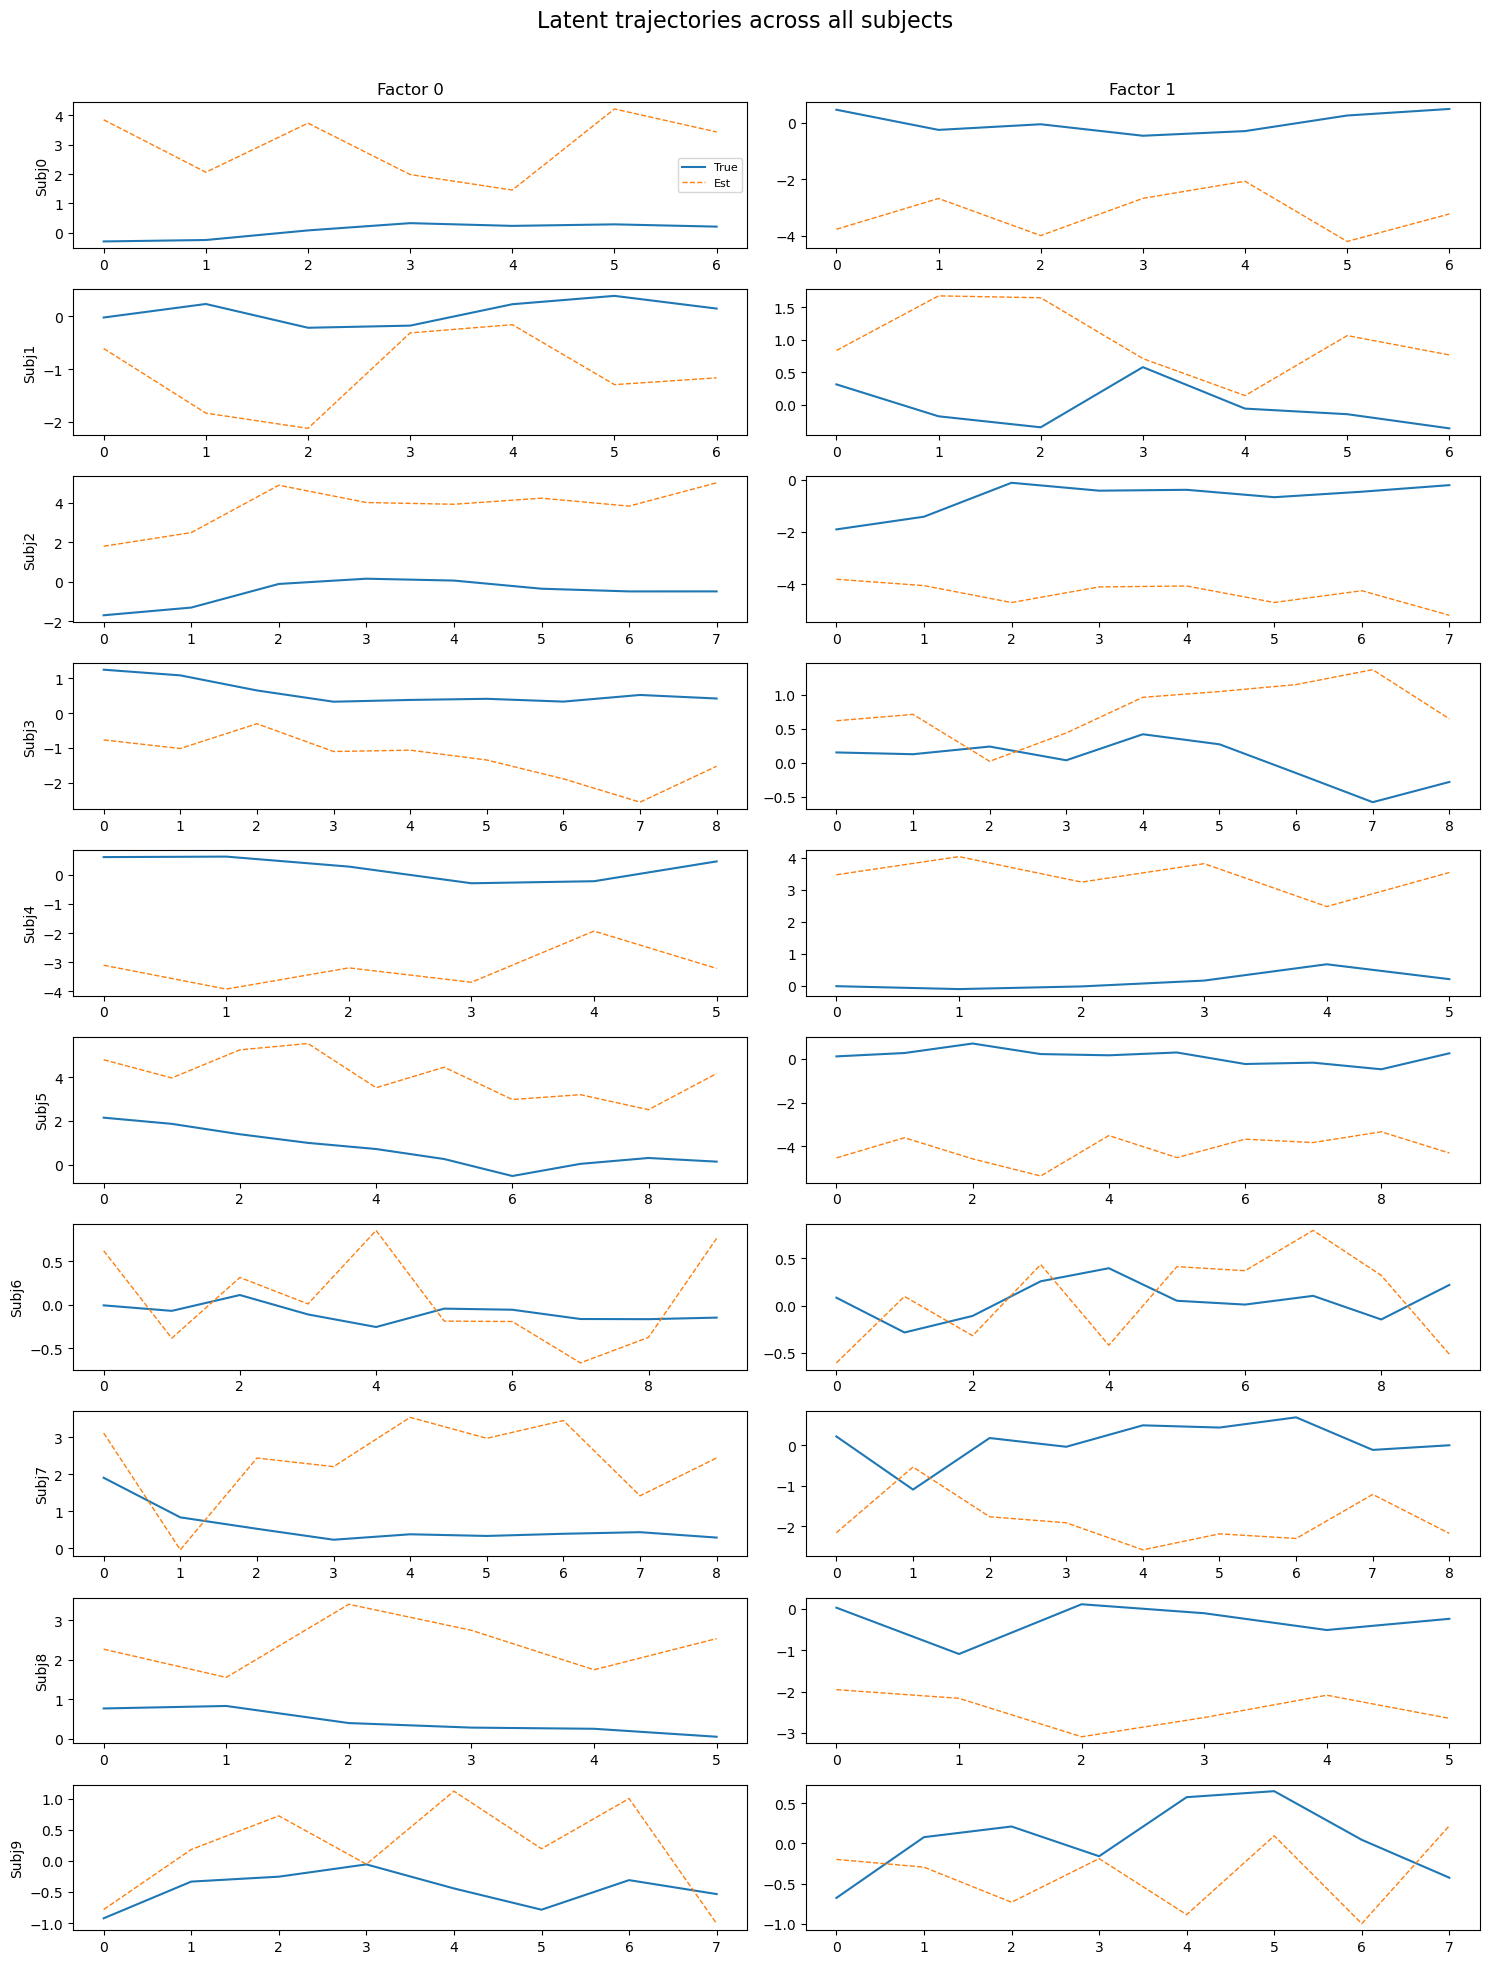

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

# ============================================================
# 1. DATA GENERATION
# ============================================================
import numpy as np
from scipy.linalg import expm

def simulate_ou_dfa(
    seed,
    n_subjects=10,
    T_list=(7, 7, 8, 9, 6, 10, 10, 9, 6, 8),
    p=5,
    k=2,
):
    rng = np.random.default_rng(seed)
    Nsub = n_subjects
    N = sum(T_list)

    # -------------------------------
    # Factor loadings (known)
    # -------------------------------
    # Lambda = rng.normal(0.8, 0.2, size=(p, k))  # observation loading
    Lambda = np.array([[1.0, 0.5],
                   [0.3, 1.2],
                   [0.0, 0.8],
                   [1.0, -0.5],
                   [0.2, 0.7]])
    # -------------------------------
    # OU latent process parameters
    # -------------------------------
    # theta_true = np.abs(rng.normal(0.5, 0.2, size=k))   # decay rates
    theta_true = np.array([0.5, 1.0])  # slower decay for factor 1, faster for factor 2
    # sigma_true = np.abs(rng.normal(0.3, 0.1, size=k))   # process noise std
    sigma_true = np.array([0.3, 0.4])  # more noise for factor 1, less for factor 2
    Q_true = np.diag(sigma_true**2)                     # process noise covariance
    Gamma = np.diag(theta_true)                         # decay matrix
    Omega = np.eye(k)                                   # initial latent covariance

    # -------------------------------
    # Random subject effects per observation
    # -------------------------------
    b_raw = rng.normal(0, 1, size=(Nsub, p))
    b = b_raw * 0.5  # shrinkage

    # -------------------------------
    # Covariates and IDs (optional, unused here)
    # -------------------------------
    cumu = np.cumsum(T_list)

    visits_list = [[0.000000, 1.383017, 2.823485, 3.369041, 4.397147, 5.789566, 6.841001], 
                 [0.0000000, 0.6470947, 2.0823945, 2.8836234, 3.4443440, 4.8920709, 6.1126672], 
                 [0.0000000, 0.5476636, 1.7485167, 2.6004054, 3.5093494, 4.8303007, 6.2491580, 7.0316864],
                 [0.0000000, 0.8142708, 1.8068373, 3.0042111, 4.1456734, 5.2895964, 6.7674498, 7.6821851, 8.3015899],
                 [0.000000, 1.310398, 1.904315, 3.226345, 4.153773, 5.409660], 
                 [0.0000000, 0.5161605, 1.0638705, 2.4932211, 3.7625067, 4.4635873, 5.6138488, 6.7676155, 7.6628692, 8.9751741],
                 [0.0000000, 0.9289406, 2.0597142, 3.0805565, 4.2401779, 5.4695388, 6.4563617, 7.3408183, 7.8476518, 8.3513360],
                 [0.000000, 1.389021, 2.313474, 2.855834, 4.003276, 4.971896, 6.089822, 6.860637, 7.517932],
                 [0.000000, 1.065465, 2.395089, 3.537203, 4.428702, 5.638282],
                 [0.0000000, 0.7718902, 1.3874727, 1.9168093, 3.2236646, 4.2037910, 5.5100390, 6.0890446]
                 ]
    # -------------------------------
    # Latent factors (OU)
    # -------------------------------
    xi = np.zeros((N, k))
    dts_all = []

    for i_sub in range(Nsub):
        T_i = T_list[i_sub]
        start_idx = cumu[i_sub] - T_i

        # Random time increments per subject
        dt_i = [visits_list[i_sub][i+1] - visits_list[i_sub][i] for i in range(len(visits_list[i_sub])-1)]
        dts_all.append(dt_i)

        # Initial latent state
        xi[start_idx] = rng.multivariate_normal(np.zeros(k), Omega)

        for t in range(1, T_i):
            idx = start_idx + t
            dt = dt_i[t-1]

            # OU discrete-time update
            A = expm(-Gamma * dt)               # decay
            Cov = Q_true - A @ Q_true @ A.T     # covariance for discrete step
            xi[idx] = rng.multivariate_normal(A @ xi[idx-1], Cov)

    # -------------------------------
    # Observed Ys (DFA: linear mapping + noise + subject effect)
    # -------------------------------
    Ys = []
    for i_sub in range(Nsub):
        T_i = T_list[i_sub]
        start_idx = cumu[i_sub] - T_i
        Y_i = np.zeros((T_i, p))
        for t in range(T_i):
            i = start_idx + t
            eta = xi[i] @ Lambda.T + b[i_sub]  # latent contribution + subject effect
            Y_i[t] = eta + rng.normal(0, 0.1, size=p)  # observation noise
        Ys.append(Y_i)

    # -------------------------------
    # Subject-specific latent trajectories
    # -------------------------------
    Zs = [xi[cumu[i]-T_list[i]:cumu[i], :] for i in range(Nsub)]

    return Ys, Zs, Lambda, theta_true, Q_true, dts_all



# ============================================================
# 2. KALMAN SMOOTHER
# ============================================================

def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]
    m, P = np.zeros(k), np.eye(k)
    m_f, P_f = [], []

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            m = A @ m
            P = A @ P @ A.T + Q

        S = Lambda @ P @ Lambda.T + Psi + 1e-6*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        m_f.append(m)
        P_f.append(P)

    Ez, Ezz, Ezztm1 = [None]*T, [None]*T, [None]*(T-1)
    Ez[-1] = m_f[-1]
    Ezz[-1] = P_f[-1] + np.outer(Ez[-1], Ez[-1])

    for t in reversed(range(T-1)):
        A = np.exp(-rho * dt[t]) * np.eye(k)
        P_pred = A @ P_f[t] @ A.T + Q
        J = P_f[t] @ A.T @ np.linalg.inv(P_pred)

        Ez[t] = m_f[t] + J @ (Ez[t+1] - A @ m_f[t])
        P = P_f[t] + J @ (Ezz[t+1] - P_pred) @ J.T

        Ezz[t] = P + np.outer(Ez[t], Ez[t])
        Ezztm1[t] = J @ Ezz[t+1]

    return Ez, Ezz, Ezztm1

# ============================================================
# 3. EM STEP
# ============================================================
def run_em(Ys, dts_all, k, seed, n_iter=600):
    """
    EM algorithm for DFA with OU latent factors.
    Estimates:
        - Lambda: factor loadings
        - rho: OU decay rates (theta)
        - Q: continuous-time process variance (sigma^2)
    """
    rng = np.random.default_rng(seed)
    p = Ys[0].shape[1]

    # -------------------------------
    # Initialize parameters
    # -------------------------------
    Lambda = rng.normal(1.0, 0.1, size=(p, k))
    Psi = np.eye(p)
    rho = np.ones(k) * 0.5
    Q_discrete = np.eye(k) * 0.1  # discrete-time covariance

    hist_L, hist_mse = [], []
    eps = 1e-8

    for _ in range(n_iter):
        Ezs, Ezzs, Ezztm1s = [], [], []

        # ---------------- E-step ----------------
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz, Ezztm1 = kalman_smoother(Y, Lambda, Psi, rho, Q_discrete, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
            Ezztm1s.append(Ezztm1)

        # ---------------- M-step: Psi ----------------
        Psi = np.diag(np.mean([
            (Ys[s][t] - Lambda @ Ezs[s][t])**2
            for s in range(len(Ys)) for t in range(len(Ys[s]))
        ], axis=0))

        # ---------------- M-step: rho / Q_discrete ----------------
        for dim in range(k):
            # ---- rho (theta) update ----
            num, denom = 0.0, 0.0
            for Ezz, Ezztm1, dt in zip(Ezzs, Ezztm1s, dts_all):
                for t, dt_val in enumerate(dt):
                    num += (Ezz[t][dim, dim] - Ezztm1[t][dim, dim])
                    denom += dt_val * Ezz[t][dim, dim]
            rho[dim] = np.clip(num / (denom + eps), 0.05, 2.0)

            # ---- Q_discrete update ----
            num_q, denom_q = 0.0, 0.0
            for Ezz, Ezztm1, dt in zip(Ezzs, Ezztm1s, dts_all):
                for t, dt_val in enumerate(dt):
                    exp1 = np.exp(-rho[dim] * dt_val)
                    num_q += Ezz[t+1][dim, dim] - 2 * exp1 * Ezztm1[t][dim, dim] + exp1**2 * Ezz[t][dim, dim]
                    denom_q += 1.0
            Q_discrete[dim, dim] = max(num_q / (denom_q + eps), eps)

        # ---------------- MSE ----------------
        mse = np.mean([
            np.mean((Ys[s] - np.array(Ezs[s]) @ Lambda.T)**2)
            for s in range(len(Ys))
        ])
        hist_L.append(Lambda.copy())
        hist_mse.append(mse)

    # ---------------- CONVERT discrete Q to continuous sigma^2 ----------------
    sigma2 = np.zeros((k, k))
    for dim in range(k):
        numerator, denominator = 0.0, 0.0
        for Ezz, Ezztm1, dt in zip(Ezzs, Ezztm1s, dts_all):
            for t, dt_val in enumerate(dt):
                exp2 = np.exp(-2 * rho[dim] * dt_val)
                numerator += 2 * rho[dim] * Q_discrete[dim, dim]
                denominator += (1 - exp2)
        sigma2[dim, dim] = numerator / (denominator + eps)

    return Lambda, rho, sigma2, hist_L, hist_mse, Ezs





# ============================================================
# 4. MULTI-RUN EXPERIMENT
# ============================================================

def multi_run_experiment(n_runs=5):
    rec_curves, mse_curves = [], []
    rhos, traces_Q, Qs = [], [], []

    for seed in range(n_runs):
        Ys, Zs, L_true, theta_true, Q_true, dts = simulate_ou_dfa(seed)
        Lambda_est, rho_est, Q_est, hist_L, hist_mse, Ezs = run_em(Ys, dts, k=L_true.shape[1], seed=seed)

        # factor recovery
        rec = []
        for Lh in hist_L:
            R,_ = orthogonal_procrustes(Lh, L_true)
            rec.append(np.corrcoef(L_true.ravel(), (Lh@R).ravel())[0,1])

        rec_curves.append(rec)
        mse_curves.append(hist_mse)
        rhos.append(rho_est)
        traces_Q.append(np.trace(Q_est))
        Qs.append(Q_est)

    return np.array(rec_curves), np.array(mse_curves), rhos, traces_Q, Qs, L_true, Lambda_est, theta_true, Q_true, Zs, Ezs, Ys
# ============================================================
# 5. VISUALIZATION
# ============================================================


def visualize_all(rec_curves, mse_curves, rhos, traces_Q, Lambda_true, Lambda_est, rho_true, Q_true, Z_true, Z_est, Y_true, Y_hat):
    n_runs, n_iter = rec_curves.shape
    x = np.arange(n_iter)

    # ----------------- 1. Global convergence -----------------
    # plt.figure()
    # plt.plot(x, rec_curves.mean(0))
    # plt.fill_between(x, rec_curves.mean(0)-rec_curves.std(0), rec_curves.mean(0)+rec_curves.std(0), alpha=0.3)
    # plt.title("Factor Recovery (mean ± std)")
    # plt.xlabel("EM iteration")
    # plt.ylabel("Correlation")
    # plt.grid()
    # plt.show()

    # plt.figure()
    # plt.plot(x, mse_curves.mean(0))
    # plt.fill_between(x, mse_curves.mean(0)-mse_curves.std(0), mse_curves.mean(0)+mse_curves.std(0), alpha=0.3)
    # plt.title("Reconstruction Error (mean ± std)")
    # plt.xlabel("EM iteration")
    # plt.ylabel("MSE")
    # plt.grid()
    # plt.show()

    # ----------------- 2. Parameter identifiability -----------------
    # plt.figure()
    # plt.hist(rhos, bins=10, alpha=0.7)
    # plt.axvline(rho_true.mean(), color='r', linestyle='--', label="True mean ρ")
    # plt.title("Estimated ρ distribution")
    # plt.legend()
    # plt.grid()
    # plt.show()

    # plt.figure()
    # plt.hist(traces_Q, bins=10, alpha=0.7)
    # plt.axvline(np.trace(Q_true), color='r', linestyle='--', label="True tr(Q)")
    # plt.title("Estimated tr(Q) distribution")
    # plt.legend()
    # plt.grid()
    # plt.show()

    # ----------------- 3. Factor loadings -----------------
    R,_ = orthogonal_procrustes(Lambda_est, Lambda_true)
    L_align = Lambda_est @ R

    # plt.figure(figsize=(6,6))
    # for kf in range(Lambda_true.shape[1]):
    #     plt.scatter(Lambda_true[:,kf], L_align[:,kf], label=f"Factor {kf}")
    # plt.plot([-1,1],[-1,1],'k--')
    # plt.legend()
    # plt.title("Λ recovery (Procrustes aligned)")
    # plt.xlabel("True")
    # plt.ylabel("Estimated")
    # plt.grid()
    # plt.show()

    # plt.figure(figsize=(10,4))
    # plt.subplot(1,2,1)
    # plt.imshow(np.abs(Lambda_true), aspect='auto')
    # plt.title("|Λ| true")
    # plt.colorbar()
    # plt.subplot(1,2,2)
    # plt.imshow(np.abs(L_align), aspect='auto')
    # plt.title("|Λ| estimated")
    # plt.colorbar()
    # plt.show()

    # cos_sim = np.sum(Lambda_true*L_align,axis=0)/(np.linalg.norm(Lambda_true,axis=0)*np.linalg.norm(L_align,axis=0))
    # plt.figure()
    # plt.bar(range(len(cos_sim)), cos_sim)
    # plt.title("Per-factor cosine similarity")
    # plt.ylim(0,1)
    # plt.grid()
    # plt.show()

    # ----------------- 4. Latent trajectories (first subject) -----------------
    Z_true_arr = np.array(Z_true[0])
    Z_est_arr = np.array(Z_est[0])
    Y_true_arr = np.array(Y_true[0])
    Y_hat_arr = np.array(Y_hat[0])
    T, k = Z_true_arr.shape

    # plt.figure(figsize=(10,6))
    # for i in range(k):
    #     plt.subplot(k,1,i+1)
    #     plt.plot(Z_true_arr[:,i], label="True", linewidth=2)
    #     plt.plot(Z_est_arr[:,i], '--', label="Estimated")
    #     if i==0:
    #         plt.legend()
    # plt.suptitle("Latent trajectories (first subject)")
    # plt.show()

    # plt.figure()
    # plt.scatter(Z_est_arr[:-1].ravel(), Z_est_arr[1:].ravel(), alpha=0.3)
    # plt.title("Latent time-lag scatter (first subject)")
    # plt.xlabel("z(t)")
    # plt.ylabel("z(t+1)")
    # plt.grid()
    # plt.show()

    # plt.figure()
    # plt.plot((Y_true_arr-Y_hat_arr).mean(1))
    # plt.title("Mean residual over time (first subject)")
    # plt.grid()
    # plt.show()

    # ----------------- 5. Latent trajectories (all subjects grid) -----------------
    n_subjects = len(Z_true)
    k = Z_true_arr.shape[1]
    plt.figure(figsize=(15, n_subjects*2))
    for s in range(n_subjects):
        Zt = np.array(Z_true[s])
        Ze = np.array(Z_est[s])
        T = Zt.shape[0]
        for f in range(k):
            plt.subplot(n_subjects, k, s*k + f + 1)
            plt.plot(range(T), Zt[:,f], label="True", linewidth=1.5)
            plt.plot(range(T), Ze[:,f], '--', label="Est", linewidth=1)
            if s==0 and f==0:
                plt.legend(fontsize=8)
            if f==0:
                plt.ylabel(f"Subj{s}")
            if s==0:
                plt.title(f"Factor {f}")
    plt.suptitle("Latent trajectories across all subjects", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()

# ============================================================
# 6. MAIN
# ============================================================


rec_curves, mse_curves, rhos, traces_Q, Qs, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys = multi_run_experiment(n_runs=5)
Y_hat = [np.array(Ez) @ Lambda_est.T for Ez in Ezs]




visualize_all(rec_curves, mse_curves, rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys, Y_hat)


In [55]:
import math
for q in Qs:
    print(np.sqrt(q))

[[5.10911646 0.        ]
 [0.         5.34341566]]
[[0.68784498 0.        ]
 [0.         0.76207663]]
[[0.62998464 0.        ]
 [0.         0.6866018 ]]
[[2.08149452 0.        ]
 [0.         1.97123917]]
[[4.37181688 0.        ]
 [0.         4.38105423]]


In [56]:
rhos

[array([0.81124474, 0.83221209]),
 array([0.5810016 , 0.55494636]),
 array([0.64576023, 0.60221652]),
 array([1.04093417, 1.00734802]),
 array([0.97914784, 0.97179182])]

In [57]:
Qs

[array([[26.10307098,  0.        ],
        [ 0.        , 28.55209088]]),
 array([[0.47313072, 0.        ],
        [0.        , 0.58076079]]),
 array([[0.39688065, 0.        ],
        [0.        , 0.47142203]]),
 array([[4.33261946, 0.        ],
        [0.        , 3.88578385]]),
 array([[19.11278281,  0.        ],
        [ 0.        , 19.19363621]])]